**Table of contents**<a id='toc0_'></a>    
- [Photon count 1 fluorophore](#toc1_)    
  - [Transition set](#toc1_1_)    
  - [Data generation with changed radical escape rate](#toc1_2_)    
    - [Simulation](#toc1_2_1_)    
    - [Save the data](#toc1_2_2_)    
  - [Data processing and visualization](#toc1_3_)    
    - [Read the data](#toc1_3_1_)    
      - [Changed radical escape rate](#toc1_3_1_1_)    
      - [Original data](#toc1_3_1_2_)    
    - [Post-processing](#toc1_3_2_)    
      - [Changed radical escape rate and different photon collection efficiency](#toc1_3_2_1_)    
      - [Original data](#toc1_3_2_2_)    
    - [Figure](#toc1_3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photon count 1 fluorophore](#toc0_)

In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

import fluopy.analysis as an
import fluopy.blinking as bl
import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.fluorophores as fl
import fluopy.formulas as fo
import fluopy.prediction as pr
import fluopy.routines as rt
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = r"D:\python_output\Chapter_I\1_13_multi_f_et_adjustments\photon_counts_single_fluorophore"
reading_from = r"D:\python_output\Chapter_I\0_2_single_f_statistics"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Transition set](#toc0_)

In [9]:
fluorophores = fl.construct_fluorophores(name="cy5_dna", count=1)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=False,
    **rt.PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
current_rate_pet_tr = transition_set.transition_df.xs(14, level=1)["rate"].values[0]
transition_set_changed = transition_set.adjust_rates({14: current_rate_pet_tr * 10})
transition_set_changed.finalize()
transition_set.finalize()

## <a id='toc1_2_'></a>[Data generation with changed radical escape rate](#toc0_)

### <a id='toc1_2_1_'></a>[Simulation](#toc0_)

In [3]:
rng = np.random.default_rng(1)

simulation = si.Simulation(transition_set_changed)
simulation.run(size=1e6, end_time=10000, seed=rng)

Floating point precision error warning:
 The smallest safe increment is 1.82e-12.
 Everything drawn below this number might be rounded to zero
 when approaching the time limit of this simulation.
 Using the highest possible rate which occurs for example in state combination [1]
 gives a probability of 1.07e-03 for a smaller increment to be drawn.


### <a id='toc1_2_2_'></a>[Save the data](#toc0_)

In [4]:
np.save(saving_at + r"\state_series.npy", simulation.state_series)
np.save(saving_at + r"\time_series.npy", simulation.time_series)
np.save(saving_at + r"\transition_series.npy", simulation.transition_series)

## <a id='toc1_3_'></a>[Data processing and visualization](#toc0_)

### <a id='toc1_3_1_'></a>[Read the data](#toc0_)

#### <a id='toc1_3_1_1_'></a>[Changed radical escape rate](#toc0_)

In [18]:
simulation = si.Simulation(transition_set_changed)
simulation.state_series = np.load(saving_at + r"\state_series.npy")
simulation.time_series = np.load(saving_at + r"\time_series.npy")
simulation.transition_series = np.load(saving_at + r"\transition_series.npy")

#### <a id='toc1_3_1_2_'></a>[Original data](#toc0_)

In [12]:
simulation_orig = si.Simulation(transition_set)
simulation_orig.state_series = np.load(reading_from + r"\state_series.npy")
simulation_orig.time_series = np.load(reading_from + r"\time_series.npy")
simulation_orig.transition_series = np.load(reading_from + r"\transition_series.npy")

### <a id='toc1_3_2_'></a>[Post-processing](#toc0_)

#### <a id='toc1_3_2_1_'></a>[Changed radical escape rate and different photon collection efficiency](#toc0_)

In [ ]:
def emission_post_processing_2(emis, seed):
    rng = np.random.default_rng(seed)
    photon_collection_rate = fo.calculate_photon_collection_rate(NA=1.45, n1=1.51)
    emis.add_photon_collection_objective(p=photon_collection_rate * 0.5, seed=rng)
    emis.add_transmittance(p=0.9, seed=rng)  # mirror 90/100
    emis.add_transmittance(p=0.99, seed=rng)  # lens 1
    emis.add_transmittance(p=0.99, seed=rng)  # lens 2
    emis.add_quantum_efficiency(p=0.85, seed=rng)
    emis.add_poisson_noise(rate=0.6, seed=rng)
    emis.apply_threshold(threshold=10)

In [ ]:
rng = np.random.default_rng(1)
predict = pr.Prediction(transition_set_changed)
analysis = an.Analysis(simulation)

emis = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis.extract(simulation)
emission_post_processing_2(emis=emis, seed=rng)

fcs = fcs_p.FCS(emis)
fcs.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink = bl.Blinking(emis)

#### <a id='toc1_3_2_2_'></a>[Original data](#toc0_)

In [ ]:
rng = np.random.default_rng(1)
predict_orig = pr.Prediction(transition_set)
analysis_orig = an.Analysis(simulation_orig)

emis_orig = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_orig.extract(simulation_orig)
rt.emission_post_processing(emis=emis_orig, seed=rng)

fcs_orig = fcs_p.FCS(emis_orig)
fcs_orig.autocorrelate_time_points(
    exp_min=-10, exp_max=-4, points_per_base=4, base=10, normalize=True
)

blink_orig = bl.Blinking(emis_orig)

### <a id='toc1_3_3_'></a>[Figure](#toc0_)

C:\Users\vie43sq\AppData\Local\Temp\ipykernel_10696\1706841724.py:167: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
C:\Users\vie43sq\AppData\Local\Temp\ipykernel_10696\1706841724.py:168: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
C:\Users\vie43sq\AppData\Local\Temp\ipykernel_10696\1706841724.py:168: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig(
c:\Users\vie43sq\uv_envs\phd_main\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\vie43sq\uv_envs\phd_main\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\vie43sq\uv_envs\phd_main\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating

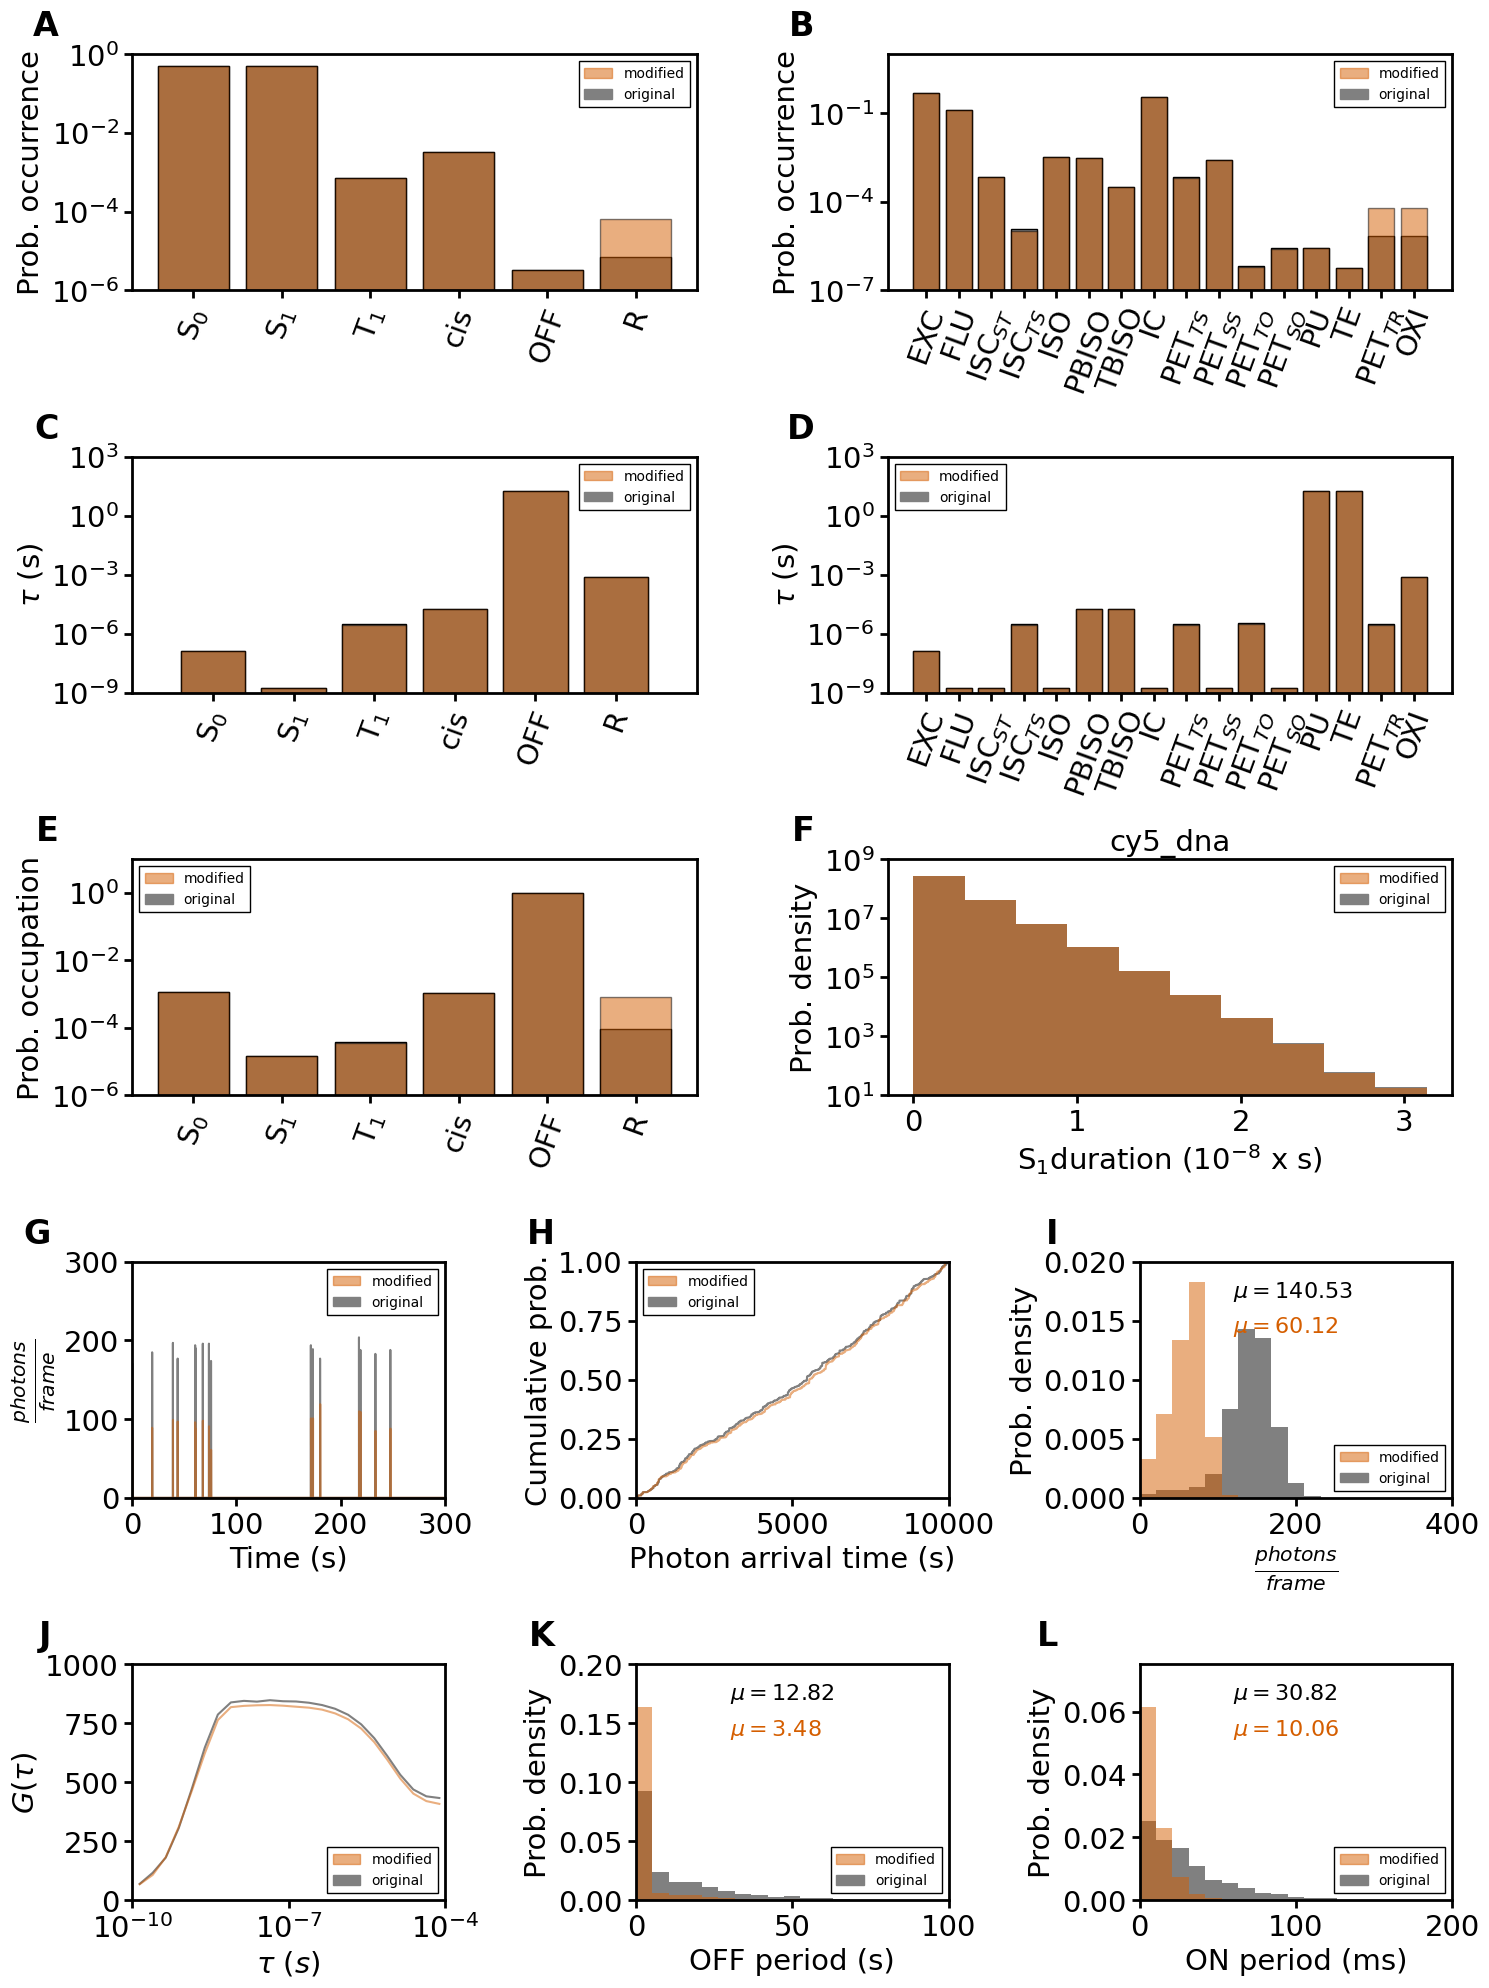

In [41]:
red = "#D55E00"


def draw_legend(ax):
    ax.legend(
        framealpha=1,
        edgecolor="black",
        fancybox=False,
        title_fontsize=10,
        handles=[
            mpl.patches.Patch(color=red, label="modified", alpha=0.5),
            mpl.patches.Patch(color="grey", label="original"),
        ],
    )


rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(5, 6)
fig = plt.figure(figsize=(15, 20))
ax = fig.add_subplot(gs[0, 0:3])
analysis_orig.plot_frequency_states(axes=ax, color="grey")
analysis.plot_frequency_states(
    ylim=[1e-6, 1e0],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[0, 3:])
analysis_orig.plot_frequency_transitions(
    axes=ax,
    color="grey",
)
analysis.plot_frequency_transitions(
    ylim=[1e-7, 1e1],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[1, 0:3])
analysis_orig.plot_mean_lifetimes(
    axes=ax,
    color="grey",
)
analysis.plot_mean_lifetimes(
    ylim=[1e-9, 1e3],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[1, 3:])
analysis_orig.plot_mean_transition_times(
    axes=ax,
    color="grey",
)
analysis.plot_mean_transition_times(
    ylim=[1e-9, 1e3],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[2, 0:3])
analysis_orig.plot_state_occupations(
    axes=ax,
    color="grey",
)
analysis.plot_state_occupations(
    ylim=[1e-6, 1e1],
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[2, 3:])
analysis_orig.plot_lifetime_distributions(
    state_identity=1,
    axes=ax,
    fluorophore="cy5_dna",
    color="grey",
)
analysis.plot_lifetime_distributions(
    state_identity=1,
    axes=ax,
    fluorophore="cy5_dna",
    color=red,
    alpha=0.5,
    title=None,
    ylim=[1e1, 1e9],
    tick_style_x="sci",
)
draw_legend(ax)

ax = fig.add_subplot(gs[3, 0:2])
emis_orig.plot_time_series(
    axes=ax,
    color="grey",
    xlim=[0, 300],
    ylim=[0, 300],
)
emis.plot_time_series(axes=ax, color=red, alpha=0.5)
draw_legend(ax)
ax = fig.add_subplot(gs[3, 2:4])
emis_orig.plot_cumulative_events(axes=ax, color="grey", xlim=[0, 10000])
emis.plot_cumulative_events(
    axes=ax,
    color=red,
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[3, 4:])
bins = np.linspace(0, 400, 20)
emis_orig.plot_histogram(
    axes=ax,
    color="grey",
    ylim=[0, 0.02],
    xlim=[0, 400],
    bins=bins,
    display_mean=True,
)
emis.plot_histogram(
    axes=ax,
    color=red,
    bins=bins,
    alpha=0.5,
    display_mean=False,
)
ax.text(
    x=0.3,
    y=0.7,
    s=rf"$\mu = {60.12}$",
    transform=ax.transAxes,
    fontsize=16,
    color=red,
)
draw_legend(ax)

ax = fig.add_subplot(gs[4, 0:2])
fcs_orig.plot(
    axes=ax, unit="s", color="grey", title=None, xlim=[1e-10, 1e-4], ylim=[0, 1000]
)
fcs.plot(
    axes=ax,
    unit="s",
    color=red,
    title=None,
    xlim=[1e-10, 1e-4],
    ylim=[0, 1000],
    alpha=0.5,
)
draw_legend(ax)
ax = fig.add_subplot(gs[4, 2:4])
bins = np.linspace(0, 100, 20)
blink_orig.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    ylim=[0, 0.2],
    xlim=[0, 100],
    color="grey",
    bins=bins,
    display_mean=True,
)
blink.plot(
    mode="off_histogram",
    axes=ax,
    as_time="s",
    ylim=[0, 0.2],
    xlim=[0, 100],
    color=red,
    alpha=0.5,
    bins=bins,
    display_mean=False,
)
ax.text(
    x=0.3,
    y=0.7,
    s=rf"$\mu = {3.48}$",
    transform=ax.transAxes,
    fontsize=16,
    color=red,
)
draw_legend(ax)
ax = fig.add_subplot(gs[4, 4:])
bins = np.linspace(0, 200, 20)
blink_orig.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    ylim=[0, 0.075],
    xlim=[0, 200],
    color="grey",
    bins=bins,
    display_mean=True,
)
blink.plot(
    mode="on_histogram",
    axes=ax,
    as_time="ms",
    ylim=[0, 0.075],
    xlim=[0, 200],
    color=red,
    alpha=0.5,
    bins=bins,
    display_mean=False,
)
ax.text(
    x=0.3,
    y=0.7,
    s=rf"$\mu = {10.06}$",
    transform=ax.transAxes,
    fontsize=16,
    color=red,
)
draw_legend(ax)
axes = fig.get_axes()
for i, (axis, letter) in enumerate(
    zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L"])
):
    offset = -0.13
    if i > 5:
        offset = -0.26
    axis.text(
        offset,
        1.05,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
fig.savefig(
    saving_at + r"\photon_count_single_fluorophore.png",
    bbox_inches="tight",
    pad_inches=0.1,
    dpi=300,
)